# White blood cells segmentation

## Getting dataset from kaggle

In [ ]:
# Create the .kaggle directory if it doesn't exist
!mkdir -p /root/.kaggle

# Move the kaggle.json file to the correct directory
!mv /content/kaggle.json /root/.kaggle/

# Set permissions for the kaggle.json file
!chmod 600 /root/.kaggle/kaggle.json

print("Kaggle API credentials have been set up.")

Kaggle API credentials have been set up.


In [ ]:
!kaggle datasets download -d jeetblahiri/bccd-dataset-with-mask

Dataset URL: https://www.kaggle.com/datasets/jeetblahiri/bccd-dataset-with-mask
License(s): unknown
 97% 2.08G/2.15G [00:23<00:01, 37.1MB/s]
100% 2.15G/2.15G [00:23<00:00, 97.9MB/s]


In [ ]:
!unzip *.zip

Archive:  bccd-dataset-with-mask.zip
  inflating: BCCD Dataset with mask/test/mask/e02301ac-68f7-4daf-b2ba-254b917f1cca.png  
  inflating: BCCD Dataset with mask/test/mask/e11515b4-9527-4c23-a0ba-43719bacca0d.png  
  inflating: BCCD Dataset with mask/test/mask/e13f2327-fbf4-4d84-a8c1-09cb1e449c8c.png  
  inflating: BCCD Dataset with mask/test/mask/e16c0dab-780d-4035-872e-1bb91e49f9d2.png  
  inflating: BCCD Dataset with mask/test/mask/e1937e32-85d5-4cd8-bb4a-b9cf8ee7ceeb.png  
  inflating: BCCD Dataset with mask/test/mask/e234ce8b-4ec4-4d93-9068-d7854d77ddf4.png  
  inflating: BCCD Dataset with mask/test/mask/e26b88c6-5884-4b5c-94d7-ad780379c8ad.png  
  inflating: BCCD Dataset with mask/test/mask/e36cb882-c6d0-4467-812e-d18c169a9a47.png  
  inflating: BCCD Dataset with mask/test/mask/e3ade58d-086c-47fa-9120-76beacb45395.png  
  inflating: BCCD Dataset with mask/test/mask/e3c1442a-717f-41dd-bf97-81e1233ac9fa.png  
  inflating: BCCD Dataset with mask/test/mask/e3e9c2de-0a24-4c7e-8a69-3d3

In [21]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset
from sklearn.cluster import KMeans

!pip install -q scikit-fuzzy
import skfuzzy as fuzz

## Pytorch Dataset

In [22]:
class BCCDDataset(Dataset):
    def __init__(self, root_dir, split="test"):
        self.root_dir = os.path.join(root_dir, split)
        self.image_dir = os.path.join(self.root_dir, "original")
        self.mask_dir = os.path.join(self.root_dir, "mask")

        self.images = sorted(os.listdir(self.image_dir))
        self.masks = sorted(os.listdir(self.mask_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, 0)
        mask = (mask > 0).astype(np.float32)

        image = torch.tensor(image, dtype=torch.float32).permute(2,0,1) / 255.0
        mask = torch.tensor(mask, dtype=torch.float32)

        return image, mask

In [23]:
train_dataset = BCCDDataset("/content/BCCD Dataset with mask", split="train")
test_dataset = BCCDDataset("/content/BCCD Dataset with mask", split="test")

## K-Means

In [24]:
def kmeans_segmentation(image, k=3):
    h, w, c = image.shape
    pixels = image.reshape(-1, c)

    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(pixels)

    return labels.reshape(h, w)

## Fuzzy C-Means

In [25]:
def fcm_segmentation(image, c=3):
    h, w, ch = image.shape
    pixels = image.reshape(-1, ch).T

    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        pixels, c=c, m=2, error=0.005, maxiter=500
    )

    labels = np.argmax(u, axis=0)
    return labels.reshape(h, w)

In [26]:
def dice_score(pred, target):
    pred = pred.flatten()
    target = target.flatten()
    intersection = (pred * target).sum()
    return (2. * intersection) / (pred.sum() + target.sum() + 1e-8)

In [27]:
def best_cluster_match(segmented, mask):
    """to map the cluster predicted to the ground turth cluster correctly"""
    best_dice = 0
    best_binary = None

    for cluster_id in np.unique(segmented):
        binary = (segmented == cluster_id).astype(np.float32)
        d = dice_score(binary, mask)

        if d > best_dice:
            best_dice = d
            best_binary = binary

    return best_binary, best_dice

In [29]:
from tqdm import tqdm

kmeans_scores = []
fcm_scores = []

num_samples = min(10, len(test_dataset))

for i in tqdm(range(num_samples), desc="Evaluating"):
    image, mask = test_dataset[i]

    image_np = image.permute(1,2,0).numpy()
    mask_np = mask.numpy()

    # KMeans
    k_out = kmeans_segmentation(image_np, k=3)
    k_binary, k_dice = best_cluster_match(k_out, mask_np)
    kmeans_scores.append(k_dice)

    # FCM
    f_out = fcm_segmentation(image_np, c=3)
    f_binary, f_dice = best_cluster_match(f_out, mask_np)
    fcm_scores.append(f_dice)

print("\nAverage Dice on Test Set")
print("KMeans:", np.mean(kmeans_scores))
print("FCM:", np.mean(fcm_scores))

Evaluating: 100%|██████████| 10/10 [08:15<00:00, 49.57s/it]


Average Dice on Test Set
KMeans: 0.763533
FCM: 0.7382604


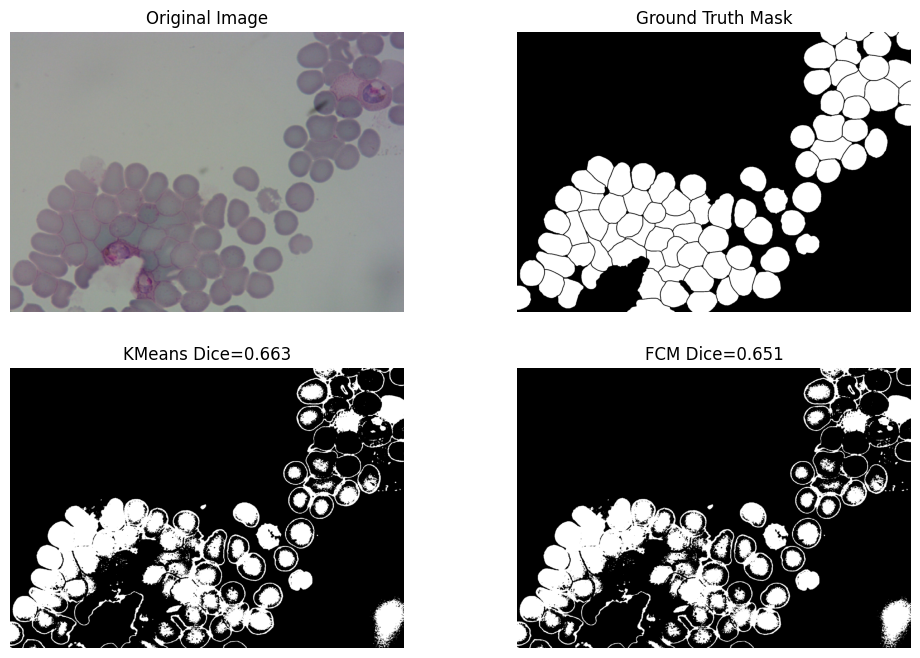

In [30]:
example_idx = 0

image, mask = test_dataset[example_idx]

image_np = image.permute(1,2,0).numpy()
mask_np = mask.numpy()

k_out = kmeans_segmentation(image_np, k=3)
k_binary, k_dice = best_cluster_match(k_out, mask_np)

f_out = fcm_segmentation(image_np, c=3)
f_binary, f_dice = best_cluster_match(f_out, mask_np)

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(image_np)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(mask_np, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(k_binary, cmap="gray")
plt.title(f"KMeans Dice={k_dice:.3f}")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(f_binary, cmap="gray")
plt.title(f"FCM Dice={f_dice:.3f}")
plt.axis("off")

plt.show()

In [33]:
def colorize_clusters(segmented):
    h, w = segmented.shape
    colored = np.zeros((h, w, 3))

    colors = {
        0: [1, 0, 0],   # Red
        1: [0, 1, 0],   # Green
        2: [0, 0, 1],   # Blue
    }

    for cluster_id in np.unique(segmented):
        colored[segmented == cluster_id] = colors[cluster_id]

    return colored

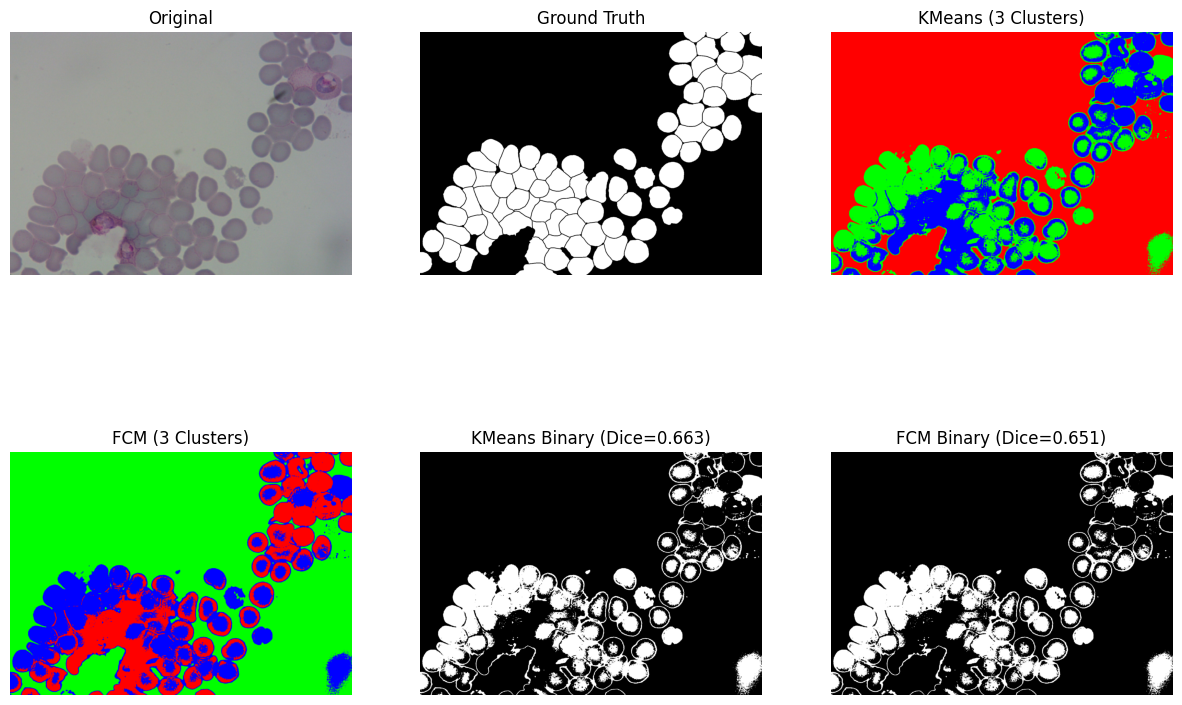

In [34]:
k_colored = colorize_clusters(k_out)
f_colored = colorize_clusters(f_out)

plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
plt.imshow(image_np)
plt.title("Original")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(mask_np, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(k_colored)
plt.title("KMeans (3 Clusters)")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(f_colored)
plt.title("FCM (3 Clusters)")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(k_binary, cmap="gray")
plt.title(f"KMeans Binary (Dice={k_dice:.3f})")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(f_binary, cmap="gray")
plt.title(f"FCM Binary (Dice={f_dice:.3f})")
plt.axis("off")

plt.show()